In [9]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
from scipy.sparse.linalg import LinearOperator, lsqr
import scipy
import time
from scipy.interpolate import lagrange

from ader_dg_transport.ader_dg_2D import wave_ader_implicit
from ader_dg_transport.ader_dg_2D import wave_ader_implicit_adjoint
import importlib

In [10]:
xlim = 10.0
ylim = 10.0
nx = 5
ny = 5
poly_order = 5
c = 1.0
tend = 2.5

In [11]:
# Todo:
# - iterable solver
# - variable c
# - free surface boundaries

# Reconstruct from final state

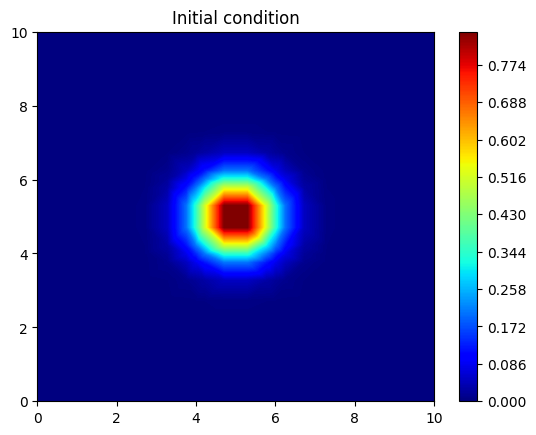

In [12]:
importlib.reload(wave_ader_implicit)
importlib.reload(wave_ader_implicit_adjoint)

cfl = 0.1
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

forward_solver = wave_ader_implicit.WaveAderDG2DImplicit(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt, a=0.5)
adjoint_solver = wave_ader_implicit_adjoint.WaveAderDG2DImplicitAdjoint(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt, a=forward_solver.a)

xs = forward_solver.xs[:, :, 0]
ys = forward_solver.ys[:, :, 0]
h0 = np.exp(-(xs - 5)**2 -(ys - 5)**2)

plt.title(f'Initial condition')
plt.tricontourf(xs.ravel(), ys.ravel(), h0.ravel(), levels=1000, cmap='jet')
plt.colorbar()

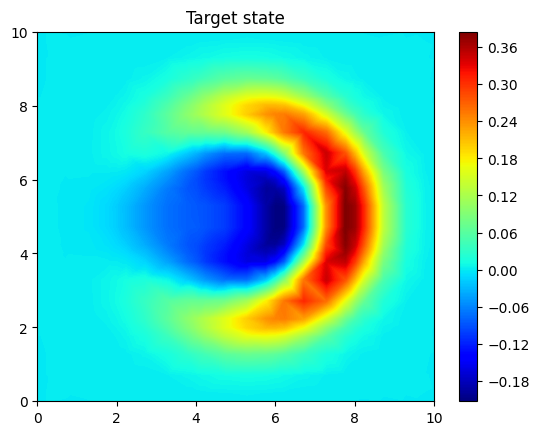

In [13]:
xs = forward_solver.xs[:, :, 0]
ys = forward_solver.ys[:, :, 0]

forward_solver.u[:] = h0
forward_solver.v[:] = 0.0
forward_solver.h[:] = h0

target_ic = np.copy(forward_solver.state)

for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)

target_state = np.copy(forward_solver.state)

plt.title(f'Target state')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.h.ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Reconstruct from final state

In [14]:
reconstructed_ic = np.ones_like(target_state)

# calculate initial error
forward_solver.state[:] = reconstructed_ic
for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)

error = forward_solver.state - target_state

print(forward_solver.norm(*forward_solver.get_vars(error**2)))

# iterate
for _ in range(2):
    
    adjoint_solver.state[:] = error
    for _ in range(nsteps):
        adjoint_solver.time_step(verbose=False, maxiter=100, tol=1e-6)

    reconstructed_ic -= adjoint_solver.state

    forward_solver.state[:] = reconstructed_ic
    for _ in range(nsteps):
        forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
    
    error = forward_solver.state - target_state
    
    print(forward_solver.norm(*forward_solver.get_vars(error**2)))
    # break

17.08072092205286
1.933108655619749e-05
1.4785226235914491e-06


### gradient check

In [15]:
# du0 = np.random.random(forward_solver.state.shape)
# forward_solver.state[:] = du0
# for _ in range(nsteps):
#     forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)

# du1 = np.copy(forward_solver.state)

# forward_solver.u[:] = h0
# forward_solver.v[:] = 0.0
# forward_solver.h[:] = h0
# forward_solver.state[:] += du0
# for _ in range(nsteps):
#     forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)

# u1 = np.copy(forward_solver.state)

# # sanity check
# print(np.allclose(target_state + du1, u1))

In [16]:
# reconstructed_ic = np.ones_like(target_state)

# # calculate initial error
# forward_solver.state[:] = reconstructed_ic
# for i in range(nsteps):
#     forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)

# error0_ = forward_solver.state - target_state
# error0 = 0.5*forward_solver.norm(*forward_solver.get_vars(error0_))**2

In [17]:
# eps = 1e-3
# reconstructed_ic = np.ones_like(target_state) + eps * du0

# # calculate initial error
# forward_solver.state[:] = reconstructed_ic
# for i in range(nsteps):
#     forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)

# error1_ = forward_solver.state - target_state
# error1 = 0.5*forward_solver.norm(*forward_solver.get_vars(error1_))**2

In [18]:
# print(error1 - error0)
# print((forward_solver.weights_2D[None, None, None] * error0_ * eps * du1).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)

In [19]:
# print((forward_solver.weights_2D[None, None, None] * adjoint_solver.state * eps * du0).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)

In [20]:
# eps = 1e-3

# dstate = (np.random.random(adjoint_solver.state.shape) - 0.5)
# reconstructed_ic = np.ones_like(target_state) + eps * dstate

# # calculate initial error
# forward_solver.state[:] = reconstructed_ic
# for i in range(nsteps):
#     forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)

# error3_ = forward_solver.state - target_state
# error3 = 0.5*forward_solver.norm(*forward_solver.get_vars(error3_))**2

# print(error3 - error0)
# print((forward_solver.weights_2D[None, None, None] * adjoint_solver.state * eps * dstate).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)

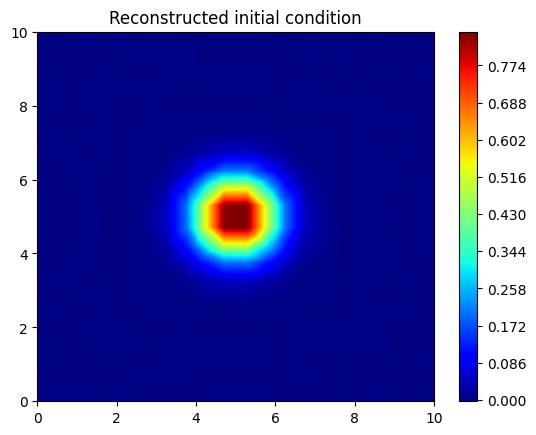

In [21]:
u, v, h = forward_solver.get_vars(reconstructed_ic)
plt.title(f'Reconstructed initial condition')
plt.tricontourf(xs.ravel(), ys.ravel(), h.ravel(), levels=1000, cmap='jet')
plt.colorbar()

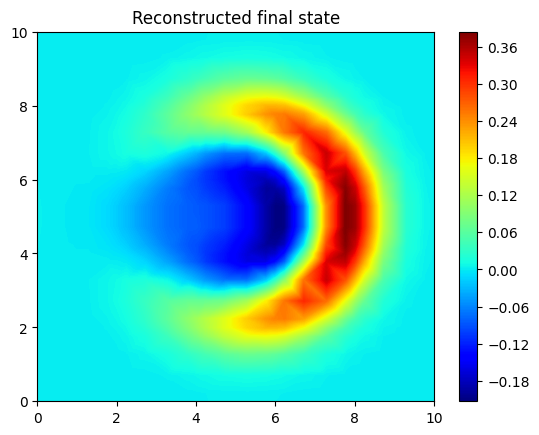

In [22]:
forward_solver.state[:] = reconstructed_ic
for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
        
plt.title(f'Reconstructed final state')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.h.ravel(), levels=1000, cmap='jet')
plt.colorbar()

# Reconstruct from receiver

In [23]:
# nsteps = 26
nsteps = 100

In [24]:
n = forward_solver.poly_order + 1
target_data = np.zeros((nsteps, ny, 3, n, n))
data = np.zeros((nsteps, ny, 3, n, n))

In [25]:
forward_solver.a

0.5

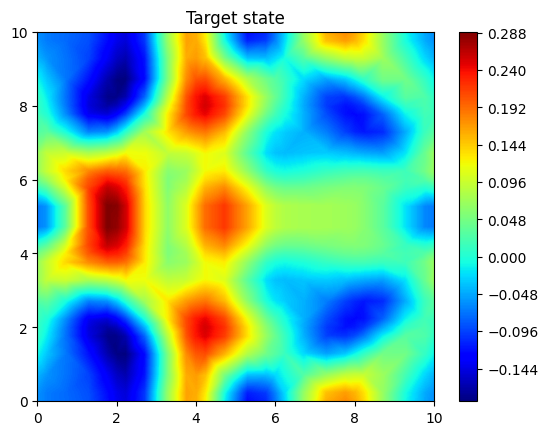

In [26]:
forward_solver.u[:] = h0
forward_solver.v[:] = 0.0
forward_solver.h[:] = h0

for i in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
    target_data[i] = forward_solver.state_pred[-4, :, :, :, -1, :]

target_state = np.copy(forward_solver.state)

plt.title(f'Target state')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.h.ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [27]:
weights_3D = forward_solver.weights_2D[None] * forward_solver.weights_x[:, None, None]

In [463]:
# reconstructed_ic = np.ones_like(target_state)

# # calculate initial error
# forward_solver.state[:] = reconstructed_ic
# for i in range(nsteps):
#     forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
#     data[i] = forward_solver.state_pred[-4, :, :, :, -1, :]

# error = (data - target_data)
# # error = error * 
# print(0.5 * (error**2).sum())

# # iterate
# for _ in range(20):
    
#     adjoint_solver.state[:] = 0.0

#     for i in range(nsteps):
#         rhs[:] = 0.0
#         rhs[-4, :, :, :, -1, :] += error[nsteps - 1 - i, :, :, ::-1]
#         rhs /= weights_3D[None, None, None]
#         rhs /= forward_solver.dx * forward_solver.dy * 0.25
#         rhs += adjoint_solver.get_rhs(adjoint_solver.state)
#         adjoint_solver.time_step(verbose=False, maxiter=100, tol=1e-6, rhs_in=rhs)

#     a = 0.5 * (error**2).sum() / adjoint_solver.norm(*adjoint_solver.get_vars(adjoint_solver.state))**2
#     reconstructed_ic -= 0.1 * a * adjoint_solver.state
#     # reconstructed_ic -= 0.001 * adjoint_solver.state * adjoint_solver.weights_2D[None, None, None] * 0.25 * forward_solver.dx * forward_solver.dy

#     forward_solver.state[:] = reconstructed_ic
#     for i in range(nsteps):
#         forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
#         data[i] = forward_solver.state_pred[-4, :, :, :, -1, :]

#     error = (data - target_data)
    
#     print(0.5 * (error**2).sum())

# Try CG

In [42]:
W_half = np.sqrt(adjoint_solver.weights_2D)[None, None, None] * adjoint_solver.dy * adjoint_solver.dt * 0.25
M_half_inv = 1 / (np.sqrt(adjoint_solver.weights_2D)[None, None, None] * adjoint_solver.dy * adjoint_solver.dx * 0.25)
M_half = (np.sqrt(adjoint_solver.weights_2D)[None, None, None] * adjoint_solver.dy * adjoint_solver.dx * 0.25)

In [34]:
def G_matvec(u0_vec):
    # 1) reshape u0

    n = forward_solver.poly_order + 1
    data = np.zeros((nsteps, ny, 3, n, n))
    
    forward_solver.state[:] = u0_vec.reshape(forward_solver.state.shape) * M_half_inv
    for i in range(nsteps):
        forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
        data[i] = forward_solver.state_pred[-4, :, :, :, -1, :]

    data *= W_half
    return data.ravel()


def G_rmatvec(y_vec):
    # y_vec has size m = Nrec*Nt
    data = y_vec.reshape((nsteps, ny, 3, n, n))
    data = data * W_half

    adjoint_solver.state[:] = 0.0

    rhs = np.zeros_like(forward_solver.state_pred)
    for i in range(nsteps):
        rhs[:] = 0.0
        rhs[-4, :, :, :, -1, :] += data[nsteps - 1 - i, :, :, ::-1]
        rhs /= weights_3D[None, None, None]
        # rhs /= adjoint_solver.weights_x[-1]
        rhs /= adjoint_solver.dx * adjoint_solver.dy * 0.25
        rhs += adjoint_solver.get_rhs(adjoint_solver.state)
        adjoint_solver.time_step(verbose=False, maxiter=100, tol=1e-6, rhs_in=rhs)

    # adjoint solve with forcing at receivers = y(t, rec)
    # returns gradient wrt u0 as a field
    grad_u0 = adjoint_solver.weights_2D[None, None, None] * adjoint_solver.state * 0.25 * adjoint_solver.dx * adjoint_solver.dy
    grad_u0 *= M_half_inv
    return grad_u0.ravel()

In [35]:
i = 10
j = 27

v1 = np.zeros(target_data.size)
v2 = np.zeros(adjoint_solver.state.size)

v1[i] = 1.0
v2[j] = 1.0
print((v1 * G_matvec(v2)).sum())

4.8189896284824864e-08


In [36]:
print((v2 * G_rmatvec(v1)).sum())

# u_t + h_x = -u
# h_t + u_x = 0

# u_t - h_x = 0
# h_t - u_x = 0


4.818989628418502e-08


In [38]:
G = LinearOperator(
    shape=(target_data.size, adjoint_solver.state.size),
    matvec=G_matvec,
    rmatvec=G_rmatvec,
    dtype=np.float64
)

# d_obs is your observed receiver data, shape (Nt, Nrec)
# b = target_data.ravel()
b = (target_data * W_half).ravel()

## First 30 iterations

In [39]:
result = lsqr(G, b, atol=1e-10, btol=1e-10, iter_lim=30)
print(result[3])

0.016560879177229617


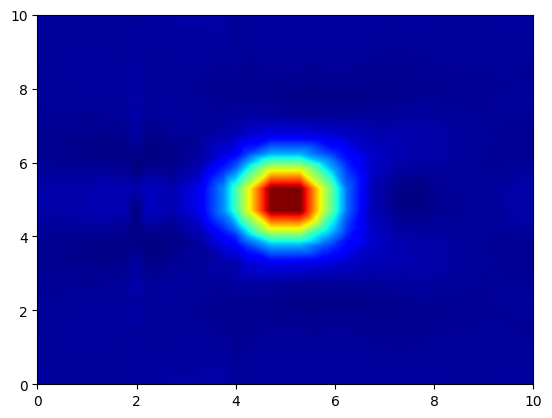

In [48]:
u0_est = result[0].reshape(forward_solver.state.shape) * M_half_inv
u, v, h = forward_solver.get_vars(u0_est)
plt.tricontourf(xs.ravel(), ys.ravel(), h.ravel(), levels=1000, cmap='jet')

## After 60 iterations

In [50]:
result = lsqr(G, b, atol=1e-10, btol=1e-10, iter_lim=30, x0=result[0])
print(result[3])

0.0034717502262522904


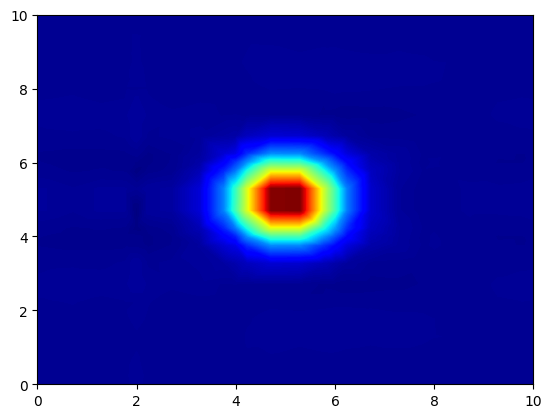

In [51]:
u0_est = result[0].reshape(forward_solver.state.shape) * M_half_inv
u, v, h = forward_solver.get_vars(u0_est)
plt.tricontourf(xs.ravel(), ys.ravel(), h.ravel(), levels=1000, cmap='jet')

## After 90 iterations

In [52]:
result = lsqr(G, b, atol=1e-10, btol=1e-10, iter_lim=30, x0=result[0])
print(result[3])

0.001425563959536103


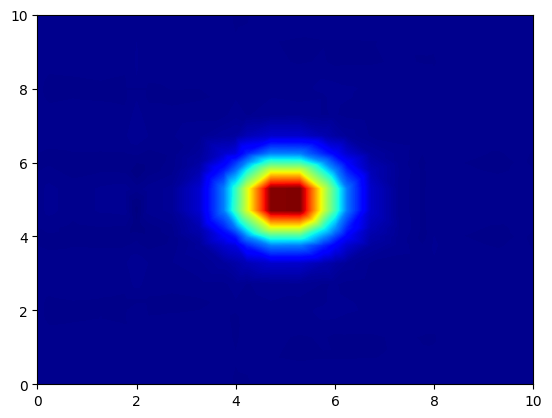

In [53]:
u0_est = result[0].reshape(forward_solver.state.shape) * M_half_inv
u, v, h = forward_solver.get_vars(u0_est)
plt.tricontourf(xs.ravel(), ys.ravel(), h.ravel(), levels=1000, cmap='jet')

In [32]:
u0_est = result[0].reshape(forward_solver.state.shape)
u, v, h = forward_solver.get_vars(u0_est)
plt.tricontourf(xs.ravel(), ys.ravel(), h.ravel(), levels=1000, cmap='jet')

NameError: name 'result' is not defined

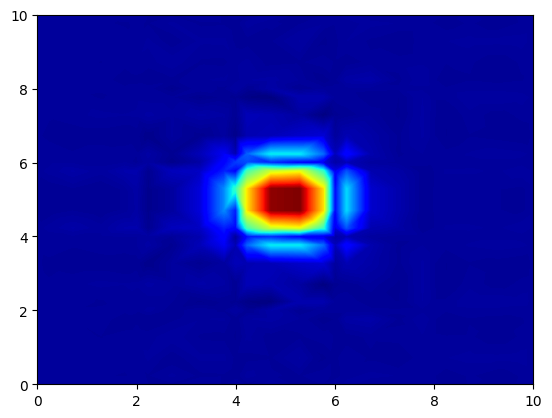

In [394]:
u0_est = result[0].reshape(forward_solver.state.shape)
u, v, h = forward_solver.get_vars(u0_est)
plt.tricontourf(xs.ravel(), ys.ravel(), h.ravel(), levels=1000, cmap='jet')

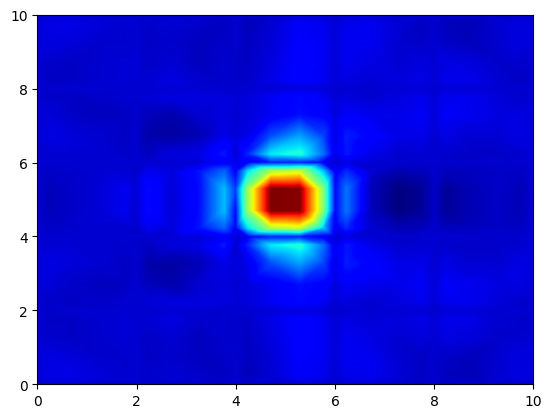

In [375]:
u, v, h = forward_solver.get_vars(u0_est)
plt.tricontourf(xs.ravel(), ys.ravel(), h.ravel(), levels=1000, cmap='jet')

In [359]:
arr = G_matvec(target_ic.ravel())

In [362]:
# arr - target_data.ravel()

In [267]:
np.arange(5)[::-1]

array([4, 3, 2, 1, 0])

In [300]:
reconstructed_ic = np.ones_like(target_state)

# calculate initial error
forward_solver.state[:] = reconstructed_ic
for i in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
    data[i] = forward_solver.state_pred[-4, :, :, :, -1, :]

error0_ = (data - target_data)
error0 = 0.5*(error0_**2).sum()

In [301]:
reconstructed_ic = np.ones_like(target_state) + eps * du0

# calculate initial error
forward_solver.state[:] = reconstructed_ic
for i in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
    data[i] = forward_solver.state_pred[-4, :, :, :, -1, :]

error1_ = (data - target_data)
error1 = 0.5*(error1_**2).sum()

In [302]:
reconstructed_ic = du0

# calculate initial error
forward_solver.state[:] = reconstructed_ic
for i in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
    data[i] = forward_solver.state_pred[-4, :, :, :, -1, :]

dsamples = np.copy(data)
# error1_ = (data - target_data)
# error1 = 0.5*(error1_**2).sum()

In [303]:
print(error1 - error0)
print((error0_ * dsamples * eps).sum())

13.425851613563282
13.421048332527832


In [319]:
print((adjoint_solver.weights_2D[None, None, None] * adjoint_solver.state * eps * du0).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)

13.42104833252895


In [320]:
print((adjoint_solver.weights_2D[None, None, None] * adjoint_solver.state**2).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)

429263987.0518667


In [329]:
a = error0 / adjoint_solver.norm(*adjoint_solver.get_vars(adjoint_solver.state))**2
print((adjoint_solver.weights_2D[None, None, None] * a * adjoint_solver.state**2).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)

12579.511944968184


In [172]:
a = 0.0008
# forward_solver.state[:] = reconstructed_ic - a * adjoint_solver.state

# grad = (adjoint_solver.state * adjoint_solver.weights_2D[None, None]) * adjoint_solver.dx * adjoint_solver.dy * 0.25
dstate = np.random.random(adjoint_solver.state.shape) * a
pred = (dstate * adjoint_solver.state * adjoint_solver.weights_2D[None, None]).sum() * adjoint_solver.dx * adjoint_solver.dy * 0.25

forward_solver.state[:] = reconstructed_ic + dstate #- a * grad
for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)
    data[i] = forward_solver.state_pred[-4, :, :, :, -1, :]

error = (data - target_data)
error1 = 0.5 * (error**2).sum()
print(error1 - error0)
print(pred)
print((error1 - error0) / pred)
# print(-a * np.linalg.norm(grad))

-1459.6047210011675
0.019276603362106237
-75718.97878390986


In [132]:
adjoint_solver.dx * adjoint_solver.dy * 0.25

0.25

In [111]:
(adjoint_solver.state * adjoint_solver.weights_2D[None, None]) * adjoint_solver.dx * adjoint_solver.dy

array([[[[[ 9.69612144e-10,  5.89705326e-09,  1.37020800e-08,
            2.85188691e-08,  3.54108237e-08,  8.21443239e-09],
          [ 6.18157172e-09,  3.75335975e-08,  8.60830845e-08,
            1.76029877e-07,  2.15259435e-07,  4.95484844e-08],
          [ 9.59498272e-09,  5.82213519e-08,  1.32613407e-07,
            2.67940086e-07,  3.23335236e-07,  7.38643390e-08],
          [ 8.16245716e-09,  4.96274211e-08,  1.14202219e-07,
            2.33290869e-07,  2.83049433e-07,  6.47580259e-08],
          [ 4.00088779e-09,  2.44410670e-08,  5.77286136e-08,
            1.21601366e-07,  1.50667294e-07,  3.47907426e-08],
          [ 5.27022945e-10,  3.24515526e-09,  7.97958829e-09,
            1.74829987e-08,  2.21468957e-08,  5.15957456e-09]],

         [[-8.35041364e-14, -8.23845000e-09, -4.04247602e-08,
           -8.86412094e-08, -1.00694705e-07, -2.20452886e-08],
          [-4.27101163e-13, -4.20542761e-08, -2.06370359e-07,
           -4.52489301e-07, -5.13683386e-07, -1.12394130e-07]

In [69]:
error = (data - target_data)**2

In [74]:
(error * forward_solver.weights_x[None, None, None, :, None]).sum() * dt / 2

np.float64(449.9846584462816)

In [77]:
# forward_solver.weights_2D

In [56]:
n = forward_solver.poly_order + 1
data = np.zeros((nsteps, ny, 3, n, n))

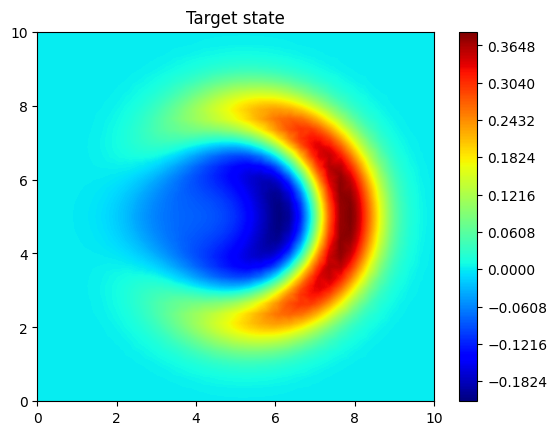

In [58]:
data.size / forward_solver.state.size

2.6

In [44]:
data.shape

(101, 10, 3, 6, 6)

In [44]:
u1 = u0 - adjoint_solver.state
forward_solver.state[:] = u1
for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6)

error = forward_solver.state - target_state

print(solver.norm(*solver.get_vars(error**2)))

5.8511808689500795e-09


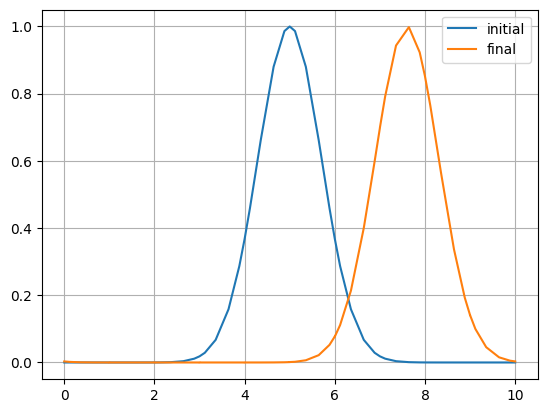

In [28]:


xs = solver.xs[:, :, 0]
ys = solver.ys[:, :, 0]
# h0 = np.exp(-(xs - 5)**2 -(ys - 5)**2)
h0 = np.exp(-(xs - 5)**2)


solver.u[:] = h0
solver.v[:] = 0.0
solver.h[:] = h0

plt.plot(xs[:, 0, :, 0].ravel(), solver.h[:, 0, :, 0].ravel(), label='initial')

while solver.time < 2.5:
    solver.time_step(verbose=False, maxiter=100, tol=1e-6)


plt.plot(xs[:, 0, :, 0].ravel(), solver.h[:, 0, :, 0].ravel(), label='final')
plt.legend()
plt.grid()
# solver.time_step(verbose=True, maxiter=100, tol=1e-6)

In [ ]:
target = np.copy(solver.state)

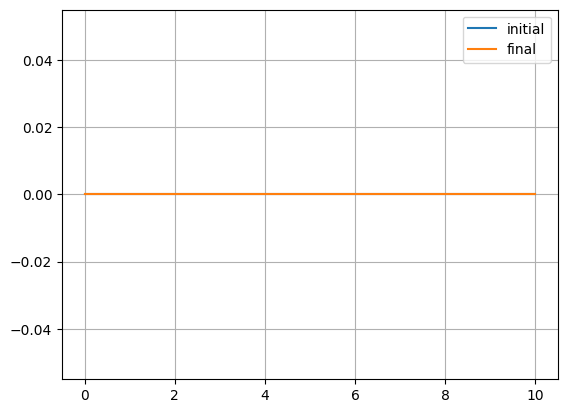

In [29]:
importlib.reload(wave_ader_implicit)

cfl = 0.1
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

adjoint_solver = wave_ader_implicit_adjoint.WaveAderDG2DImplicitAdjoint(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt)

xs = adjoint_solver.xs[:, :, 0]
ys = adjoint_solver.ys[:, :, 0]
# h0 = np.exp(-(xs - 5)**2 -(ys - 5)**2)
h0 = np.exp(-(xs - 5)**2)


adjoint_solver.u[:] = h0
adjoint_solver.v[:] = 0.0
adjoint_solver.h[:] = h0

plt.plot(xs[:, 0, :, 0].ravel(), adjoint_solver.h[:, 0, :, 0].ravel(), label='initial')

while solver.time < 2.5:
    adjoint_solver.time_step(verbose=True, maxiter=100, tol=1e-6)


plt.plot(xs[:, 0, :, 0].ravel(), adjoint_solver.h[:, 0, :, 0].ravel(), label='final')
plt.legend()
plt.grid()
# solver.time_step(verbose=True, maxiter=100, tol=1e-6)